# Modelo de predicción de tráfico

En este notebook creamos el modelo de predicción de tráfico para los 1.046 segmentos que tenemos monitorizados.

**Modelo**: vamos a usar **LightGBM (Light Gradient Boosting Machine)**, un modelo de Machine Learning basado en árboles de decisión, concretamente en **Gradient Boosting**. Lo elegimos porque maneja variables categóricas y son rápidos con millones de filas.

**Datos**: usamos `dataset_final.parquet` completo con `segment_id` como una variable más. La idea es hacer un modelo que aprenda patrones generales y use `segment_id` para diferenciar el comportamiento de cada tramo.

**Validación**: vamos a partir por fecha, para entrenar usaremos datos desde 2018 a octubre de 2025 y evaluaremos con los 6 meses restantes.



## 0. Importación de paquetes

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# carpeta de Drive
data_clean = "/content/drive/MyDrive/TFM/data_clean"

Mounted at /content/drive


In [2]:
# instalamos LightGBM
#!pip install duckdb lightgbm --quiet

In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Lag feature y split temporal
Como queremos predecir a tiempo real, usaremos la velocidad de la hora anterior en ese mismo segmento (*lag feature*), pues el tráfico se parece mucho al de una hora antes.

Nota: como nuestros datos de tráfico no son continuos al 100% (puede haber huecos de horas sin lecturas en algún segmento), `speed_lag1` nos da la hora anterior con datos, no necesariamente el de hace exactamente 1 hora.

In [4]:
con = duckdb.connect()

In [5]:
# añadimos velocidad de la hora anterior
con.sql(f"""
COPY (
    SELECT
        f.*,
        LAG(f.avg_speed, 1) OVER (
            PARTITION BY f.segment_id
            ORDER BY f.time_hour
        ) AS speed_lag1
    FROM '{data_clean}/dataset_final.parquet' f
) TO '{data_clean}/dataset_model.parquet' (FORMAT PARQUET)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Comprobamos cuántas filas se quedan sin lag (pues la primera hora de cada segmento no tiene hora anterior).

In [6]:
check_lag = con.sql(f"""
    SELECT
        COUNT(*) AS total,
        SUM(CASE WHEN speed_lag1 IS NULL THEN 1 ELSE 0 END) AS sin_lag
    FROM '{data_clean}/dataset_model.parquet'
""").df()
print(check_lag)

      total  sin_lag
0  54222131   1046.0


Tenemos 1.046 filas con `speed_lag1` vacio, exactamente una por segmento de carretera.

## 2. Preparar variables para LightGBM

A continuación, separamos los datos por la fecha de corte que hemos calculado, y descartamos las filas sin lag.

Por problemas de RAM, como tenemos una gran cantidad de datos, vamos a aligerarlo reduciendo el tamaño de cada valor (tipos de dato más pequeños) y entrenando con una muestra del 20% en vez de todas las filas (test se carga completo, sin muestrear, para evaluar sobre todos los datos disponibles).

In [7]:
# split temporal
fecha_corte = "2025-10-30 01:00:00"

In [8]:
# cargamos datos divididos en train/test
train_df = con.sql(f"""
    SELECT
        CAST(segment_id AS INTEGER) AS segment_id,
        CAST(avg_speed AS FLOAT) AS avg_speed,
        CAST(school_holiday AS TINYINT) AS school_holiday,
        CAST(festivo AS TINYINT) AS festivo,
        CAST(temperature_2m AS FLOAT) AS temperature_2m,
        CAST(rain AS FLOAT) AS rain,
        CAST(snowfall AS FLOAT) AS snowfall,
        CAST(relative_humidity_2m AS FLOAT) AS relative_humidity_2m,
        CAST(wind_speed_10m AS FLOAT) AS wind_speed_10m,
        CAST(partido AS TINYINT) AS partido,
        CAST(concierto AS TINYINT) AS concierto,
        obra_tipo,
        accidente_tipo,
        CAST(hora AS TINYINT) AS hora,
        CAST(dia_semana AS TINYINT) AS dia_semana,
        CAST(mes AS TINYINT) AS mes,
        CAST(es_finde AS TINYINT) AS es_finde,
        CAST(speed_lag1 AS FLOAT) AS speed_lag1
    FROM '{data_clean}/dataset_model.parquet'
    WHERE time_hour < '{fecha_corte}' AND speed_lag1 IS NOT NULL
    USING SAMPLE 20 PERCENT (bernoulli)
""").df()

test_df = con.sql(f"""
    SELECT
        CAST(segment_id AS INTEGER) AS segment_id,
        CAST(avg_speed AS FLOAT) AS avg_speed,
        CAST(school_holiday AS TINYINT) AS school_holiday,
        CAST(festivo AS TINYINT) AS festivo,
        CAST(temperature_2m AS FLOAT) AS temperature_2m,
        CAST(rain AS FLOAT) AS rain,
        CAST(snowfall AS FLOAT) AS snowfall,
        CAST(relative_humidity_2m AS FLOAT) AS relative_humidity_2m,
        CAST(wind_speed_10m AS FLOAT) AS wind_speed_10m,
        CAST(partido AS TINYINT) AS partido,
        CAST(concierto AS TINYINT) AS concierto,
        obra_tipo,
        accidente_tipo,
        CAST(hora AS TINYINT) AS hora,
        CAST(dia_semana AS TINYINT) AS dia_semana,
        CAST(mes AS TINYINT) AS mes,
        CAST(es_finde AS TINYINT) AS es_finde,
        CAST(speed_lag1 AS FLOAT) AS speed_lag1
    FROM '{data_clean}/dataset_model.parquet'
    WHERE time_hour >= '{fecha_corte}' AND speed_lag1 IS NOT NULL
""").df()

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

print(train_df.memory_usage(deep=True).sum() / 1e9, "GB (train)")
print(test_df.memory_usage(deep=True).sum() / 1e9, "GB (test)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train: (10073432, 18)
Test: (3858763, 18)
1.532937177 GB (train)
0.586713765 GB (test)


Tenemos 10.068.083 filas para train y 3.858.763 filas para test.

Gracias a los tipos reducidos, usamos solo 1.53GB para 10 millones de filas de train (sin reducir eran unos 7GB y se nos bloqueaba el kernel).

In [9]:
# preparamos variables categoricas
columnas_categoricas = ["segment_id", "obra_tipo", "accidente_tipo", "hora", "dia_semana", "mes"]

for col in columnas_categoricas:
    train_df[col] = train_df[col].astype("category")
    test_df[col] = test_df[col].astype("category")

Como `test_df` no ha sido muestreado pero `train_df` sí, es posible que algún valor de `obra_tipo` o `accidente_tipo` que aparece en test no haya aparecido nunca en train. Vamos a comprobarlo.

In [10]:
for col in ["obra_tipo", "accidente_tipo"]:
    en_test_no_train = set(test_df[col].unique()) - set(train_df[col].unique())
    print(f"{col}: categorías en test que no están en train -> {en_test_no_train}")

obra_tipo: categorías en test que no están en train -> set()
accidente_tipo: categorías en test que no están en train -> set()


Salen los dos conjuntos vacíos, así que no hay problemas.

In [11]:
# separamos features (X) y objetivo (y)
columnas_excluir = ["avg_speed"]

X_train = train_df.drop(columns=columnas_excluir)
y_train = train_df["avg_speed"]

X_test = test_df.drop(columns=columnas_excluir)
y_test = test_df["avg_speed"]

print(X_train.shape, X_test.shape)

(10073432, 17) (3858763, 17)


## 3. Entrenar el modelo

In [12]:
# pasamos x_train y y_train a lightgbm con columnas categoricas
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=columnas_categoricas)
test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=columnas_categoricas, reference=train_data)

# configuracion modelo
params = {
    "objective": "regression",  # problema de regresion
    "metric": "mae",    # error absoluto medio
    "learning_rate": 0.05, # cuánto aprende el modelo en cada paso
    "num_leaves": 63,   # complejidad de cada árbol individual
    "verbose": -1,
}

# entrenamos
modelo = lgb.train(
    params,
    train_data,
    num_boost_round=500,    # max arboles
    valid_sets=[train_data, test_data],
    valid_names=["train", "test"],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(50)],
)

Training until validation scores don't improve for 30 rounds
[50]	train's l1: 2.16714	test's l1: 2.00981
[100]	train's l1: 2.04735	test's l1: 1.89744
[150]	train's l1: 2.01841	test's l1: 1.87688
[200]	train's l1: 2.00346	test's l1: 1.8682
[250]	train's l1: 1.99336	test's l1: 1.86246
[300]	train's l1: 1.98621	test's l1: 1.85868
[350]	train's l1: 1.98055	test's l1: 1.85586
[400]	train's l1: 1.97552	test's l1: 1.85377
[450]	train's l1: 1.97094	test's l1: 1.85202
[500]	train's l1: 1.96711	test's l1: 1.8505
Did not meet early stopping. Best iteration is:
[500]	train's l1: 1.96711	test's l1: 1.8505


In [13]:
# guardamos modelo
modelo.save_model(f"{data_clean}/modelo_trafico.txt")

Conseguimos un MAE final de 1.85km/h en test (y 1.97km/h en train), esto significa que el modelo se equivoca de media en menos de 2km/h al predecir la velocidad de un segmento en una hora. Siendo la velocidad media general del dataset alrededor de 25km/h, un error de 1.85km/h es un 7-8% de error relativo.

Train y test están muy cerca (1.97 vs 1.85), esto es señal de que el modelo no está sobreajustando y generaliza bien a datos que no ha visto.

Además, el modelo llega a las 500 rondas máximas sin que el early stopping se active, el error seguía bajando aunque cada vez más despacio.

In [14]:
# cargamos modelo
modelo = lgb.Booster(model_file=f"{data_clean}/modelo_trafico.txt")

## 4. Evaluación del modelo

### 4.1. Métricas adicionales

- **MAE:** error medio absoluto.
- **RMSE:** penaliza mucho más que MAE los errores grandes.
- **$R^2$:** la proporción de la variabilidad de la velocidad real explicada por el modelo.


In [15]:
y_pred = modelo.predict(X_test, num_iteration=modelo.best_iteration)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f} km/h")
print(f"RMSE: {rmse:.3f} km/h")
print(f"R²:   {r2:.4f}")

MAE:  1.850 km/h
RMSE: 2.571 km/h
R²:   0.8289


- RMSE = 2.573, es más alto que MAE (1.853), lo que nos confirma que hay algunos errores puntuales grandes que penalizan más al RMSE que al MAE.

- $R^2$ = 0.8286: el modelo explica el 82.86% de la variabilidad de la velocidad, un resultado bastante bueno.

### 4.2. Importancia de variables
Medimos cuánto contribuye cada variable a mejorar las predicciones del modelo en total.

                variable   importancia
16            speed_lag1  2.809197e+09
0             segment_id  4.791531e+08
12                  hora  4.562635e+07
15              es_finde  3.968740e+06
13            dia_semana  2.860134e+06
5               snowfall  2.141846e+06
14                   mes  1.761404e+06
4                   rain  1.237264e+06
3         temperature_2m  1.176115e+06
6   relative_humidity_2m  4.267455e+05
2                festivo  3.895684e+05
7         wind_speed_10m  3.720172e+05
10             obra_tipo  2.681054e+05
11        accidente_tipo  1.146343e+05
1         school_holiday  7.425459e+04
9              concierto  5.283494e+04
8                partido  4.253980e+04


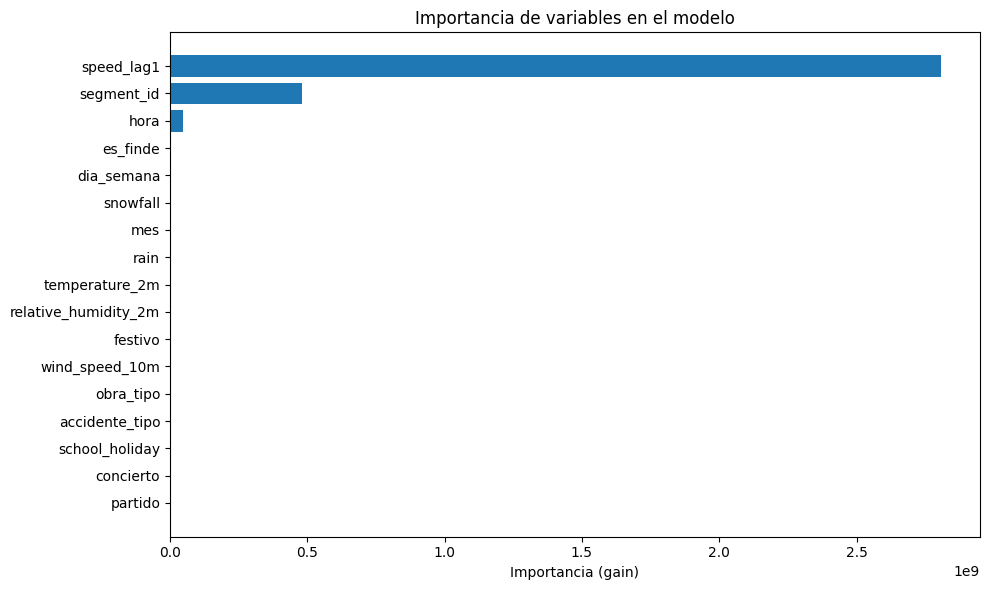

In [16]:
importancia = pd.DataFrame({
    "variable": modelo.feature_name(),
    "importancia": modelo.feature_importance(importance_type="gain")
}).sort_values("importancia", ascending=False)

print(importancia)

plt.figure(figsize=(10, 6))
plt.barh(importancia["variable"], importancia["importancia"])
plt.xlabel("Importancia (gain)")
plt.title("Importancia de variables en el modelo")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Vemos que `speed_lag1` tiene la mayor importancia con gran diferencia, tiene sentido ya que el tráfico se parece mucho a como estaba la hora anterior. Depués estan `segment_id` (identidad/velocidad base) y `hora`.

Las variable de eventos como `accidente_tipo`, `partido`, `concierto`, `obra_tipo`, etc. tienen muy baja importancia. Esto no significa que no importen conceptualmente, sino que la métrica mide cuánto contribuyen en el conjunto de todas las filas, y estos eventos afectan solo a una proporción pequeña.

Para asegurarnos de que el modelo está aprendiendo el efecto de los diferentes eventos, vamos a comparar en el test set la velocidad real media y la predicción media del modelo, separando filas con y sin cada evento.

In [17]:
def validar_evento(test_df_eval, columna, es_categorica_texto=False):
    """Esta función compara velocidad real vs predicha
    para comprobar si el modelo capta bien el efecto del evento elegido."""

    resultado = test_df_eval.groupby(columna, observed=True).agg(
        velocidad_real_media=("avg_speed", "mean"),
        prediccion_media=("y_pred", "mean"),
        n=("avg_speed", "count")
    )
    resultado["diferencia_real"] = resultado["velocidad_real_media"] - resultado["velocidad_real_media"].iloc[0]
    resultado["diferencia_predicha"] = resultado["prediccion_media"] - resultado["prediccion_media"].iloc[0]

    print(f"\n{columna}")
    print("="*20)
    print(resultado)
    return resultado

In [18]:
test_df_eval = test_df.copy()
test_df_eval["y_pred"] = y_pred
test_df_eval["error_abs"] = np.abs(test_df_eval["avg_speed"] - test_df_eval["y_pred"])

validar_evento(test_df_eval, "partido")
validar_evento(test_df_eval, "concierto")
validar_evento(test_df_eval, "festivo")
validar_evento(test_df_eval, "school_holiday")


partido
         velocidad_real_media  prediccion_media        n  diferencia_real  \
partido                                                                     
0                   25.004133         25.190776  3839931         0.000000   
1                   23.532814         23.750741    18832        -1.471319   

         diferencia_predicha  
partido                       
0                   0.000000  
1                  -1.440035  

concierto
           velocidad_real_media  prediccion_media        n  diferencia_real  \
concierto                                                                     
0                     25.002129         25.189185  3852040         0.000000   
1                     22.031332         22.068931     6723        -2.970797   

           diferencia_predicha  
concierto                       
0                     0.000000  
1                    -3.120254  

festivo
         velocidad_real_media  prediccion_media        n  diferencia_real  \
festivo     

,velocidad_real_media,prediccion_media,n,diferencia_real,diferencia_predicha
school_holiday,,,,,
0,25.015575,25.201485,3282672,0.000000,0.000000
1,24.890839,25.082681,576091,-0.124737,-0.118803


In [19]:
test_df_eval["accidente_flag"] = (test_df_eval["accidente_tipo"] != "ninguno").astype(int)

comparación_accidente = test_df_eval.groupby("accidente_flag", observed=True).agg(
    velocidad_real_media=("avg_speed", "mean"),
    prediccion_media=("y_pred", "mean"),
    n=("avg_speed", "count")
)
print("accidentes")
print("="*20)
print(comparación_accidente)

accidentes
                velocidad_real_media  prediccion_media        n
accidente_flag                                                 
0                          25.022116         25.209084  3813587
1                          22.872746         23.045039    45176


In [20]:
test_df_eval["obra_flag"] = (test_df_eval["obra_tipo"] != "ninguna").astype(int)

comparación_obra = test_df_eval.groupby("obra_flag", observed=True).agg(
    velocidad_real_media=("avg_speed", "mean"),
    prediccion_media=("y_pred", "mean"),
    n=("avg_speed", "count")
)

print("obras")
print("="*20)
print(comparación_obra)

obras
           velocidad_real_media  prediccion_media        n
obra_flag                                                 
0                     26.344931         26.510284  2227595
1                     23.156094         23.372172  1631168


Observamos que para todos los eventos el modelo replica muy bien el efecto real de cada uno, la diferencia real y la predicha son casi exactos para todos los eventos.

Vemos que en `festivos`, la diferencia es positiva, al contrario que los demás eventos. Esto se debe a que un día festivo hay menos tráfico de trabajo o colegio, pero a la misma vez, puede haber más tráfico de desplazamientos por ocio, por eso el efecto es tan pequeño.

En conclusión, con esto hemos confirmado que el modelo ha haprendido el efecto real de cada evento.

### 4.3. Predicción vs realidad

Visualizamos cada predicción como un punto (real en el eje X, predicción en el eje Y), con una muestra de 20.000 puntos. La línea roja discontinua representa una predicción perfecta. Cuanto más pegada esté la nube de puntos a la línea, mejor el modelo.

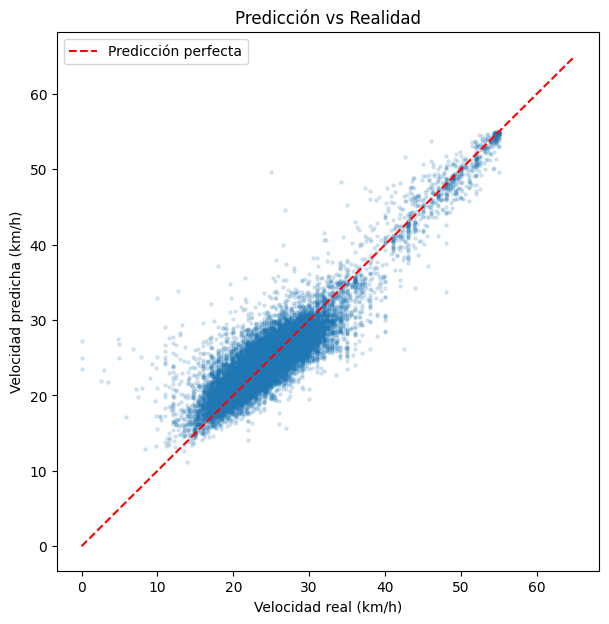

In [21]:
muestra = np.random.choice(len(y_test), 20000, replace=False)

plt.figure(figsize=(7, 7))
plt.scatter(y_test.values[muestra], y_pred[muestra], alpha=0.15, s=5)
plt.plot([0, y_test.max()], [0, y_test.max()], color="red", linestyle="--", label="Predicción perfecta")
plt.xlabel("Velocidad real (km/h)")
plt.ylabel("Velocidad predicha (km/h)")
plt.title("Predicción vs Realidad")
plt.legend()
plt.show()

Vemos un patrón en la zona central (15-40 km/h, donde estan la mayoría de los datos), la nube está pegada a la diagonal roja.

Por otro lado, en velocidades bajas (0-10 km/h reales), el modelo tiende a sobreestimar (los puntos estan por encima de la diagonal) y en velocidades altas (45-55 km/h) pasa lo contrario, el modelo tiende a infraestimar. Por lo tanto, el modelo es más fiable en el rango típico de velocidades urbanas que en los extremos.

### 4.4. Error por hora

Vamos a ver si el modelo falla más en horas punta. Para ello calculamos el MAE agrupado por hora, para ver si el modelo predice peor en según qué momentos del día.

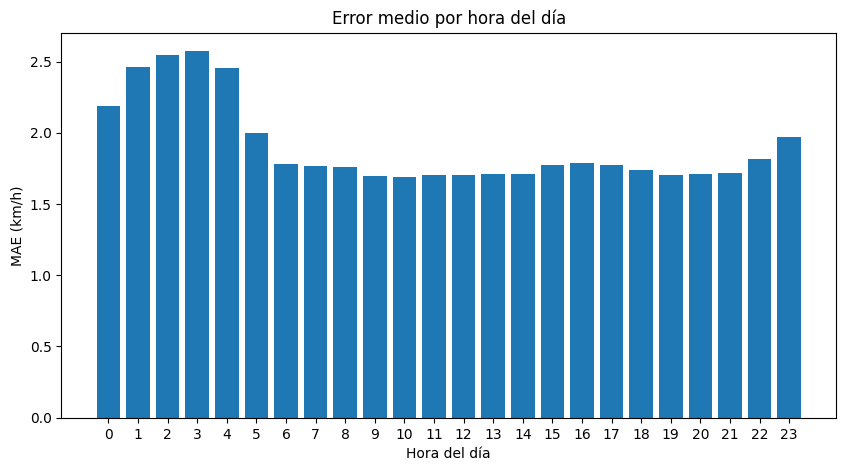

In [22]:
error_por_hora = test_df_eval.groupby("hora", observed=True)["error_abs"].mean()

plt.figure(figsize=(10, 5))
plt.bar(error_por_hora.index.astype(str), error_por_hora.values)
plt.xlabel("Hora del día")
plt.ylabel("MAE (km/h)")
plt.title("Error medio por hora del día")
plt.show()

Vemos que el error es más alto de madrugada (0-5h) que durante el día (6-21h), justo lo contrario de lo que esperabamos.

Probablemente sea porque de madrugada hay muchas menos lecturas de tráfico con pocos coches circulando, la velocidad media de esa hora-segmento puede ser más ruidosa.